# 1_rhythm_classification-gm.ipynb - M1 Max Optimized\n
\n
This notebook has been optimized for M1 Max machines running macOS Sequoia:\n
- Updated to TensorFlow 2.x with Apple Silicon support\n
- Added Metal GPU acceleration\n
- Enabled mixed precision training\n
- Updated all Keras imports to use tf.keras\n

In [1]:
# M1 Max Optimized Setup\n
import sys
sys.path.append('./rhythm_can')

# Import M1 optimization utilities\n
from rhythm_can.m1_optimization import configure_tensorflow_for_m1, get_optimized_imports

# Configure TensorFlow for M1 Max\n
tf = configure_tensorflow_for_m1()

# Get optimized imports\n
imports = get_optimized_imports()
globals().update(imports)

print('✅ M1 Max optimization complete!')

✅ Running on Apple Silicon (M1/M2)
✅ Environment variables configured
✅ TensorFlow 2.16.2 loaded
✅ Configured 1 GPU(s) with memory growth enabled
✅ Mixed precision training enabled
✅ TensorFlow configured for arm64 architecture
✅ TensorFlow 2.16.2 loaded
✅ Configured 1 GPU(s) with memory growth enabled
✅ Mixed precision training enabled
✅ TensorFlow configured for arm64 architecture
✅ Loaded 31 optimized imports
✅ M1 Max optimization complete!


In [2]:
# Constants
DRUM_CLASSES = [
   'Kick',
   'Snare',
   'Hi-hat closed',
   'Hi-hat open',
   'Tom',
   'Tambourine/Timbale', 
   'Cymbal',
   'Percussion',
   'Clap',
]

## if you want to use reddit dataset, uncomment this
MIDI_DRUM_MAP = {
    36: 0,
    35: 0,
    38: 1,
    40: 1,
    42: 2, # closed hihat
    44: 3, # pedal hihat
    46: 3, # open hihat
    41: 4, # low floor tom
    43: 4, # high floor tom
    45: 4, # low tom
    47: 4, # low-mid tom
    48: 4, # high-mid tom
    50: 4, # high tom
    54: 5, # tambourine 
    66: 5, # low timbale
    49: 6, # crash symbal 1
    51: 6, # ride  cymbal 1
    57: 6, # crash symbal 2
    59: 6, # ride cymbal 2
    67: 7, # high agogo
    58: 7, # low agogo
    69: 7, # cabasa
    70: 7, # maracas
    60: 7, # hi bongo
    61: 7, # low bongo
    62: 7, # mute hi congo
    63: 7, # open hi congo
    64: 7, # low conga
    37: 7, # side stick
    39: 8, # hand clap
}


DRUM_MIDI_MAP = [ # pianoroll to MIDI - reverse
    36, # 0 Kick / Bass Drum 1
    40, # 1 Snare / Electric Snare
    42, # 2 Hihat Closed
    46, # 3 Hihat Open
    47, # 4 Tom  / Low-mid Tom
    66, # 5 Low Timbale
    51, # 6 Cymbal
    63, # 7 Percussion / Open Hi Conga
    39  # 8 Clap
]
    
       
resolution  = 4 # separate quater into 4  = 16 notes per bar

nb_bars = 2 

len_seq = resolution * 4 * nb_bars # length of drumloops in training data - 2 bars
    
nb_notes = len(DRUM_CLASSES) # number of possible MIDI notes  - max_drum_note - min_drum_note


In [3]:
import random
import numpy as np
import os
import pretty_midi
import random
from IPython.display import Audio

import matplotlib.pyplot as plt
%matplotlib inline

MIN_NB_ONSETS = 8

drum_dists = {}

def plot_drum_matrix(a):
    if a is not None:
        a = np.transpose(np.squeeze(a))
        plt.matshow(a)
        plt.show()  

def play_drum_matrix(mat, offsets=None, tempo=120.0):
    # generate audio
    audio_data = get_audio_from_drum_matrix(mat, offsets=offsets, tempo=tempo)
    display(Audio(audio_data, rate=44100))
    return audio_data

def get_audio_from_drum_matrix(velocities, offsets=None, tempo=120.):
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo) # midi object
    pm_inst = pretty_midi.Instrument(0, is_drum=True) # midi instrument
    
    timestep = (60./tempo) / 4. # duration of a 16th note
    offset_unit = timestep / 2. # max offset == 32nd note
    
    for position, timeslot in enumerate(velocities):
        for inst, onset in enumerate(timeslot):
            if onset > 0.:
                note_number = DRUM_MIDI_MAP[inst]
                velocity = int(onset * 127.)
                
                offset = 0
                if offsets is not None:
                    offset = offsets[position, inst] * offset_unit

                start = timestep * position + offset
                end = timestep * (position + 0.5) + offset # duration doesn't matter much for rhythm track
                
                # create a midi note
                note = pretty_midi.Note(velocity=velocity, pitch=note_number, start=start, end=end)
                pm_inst.notes.append(note)
    pm.instruments.append(pm_inst)

    # midi -> audio
    audio_data = pm.fluidsynth()
    return audio_data

In [4]:
import numpy as np

# make sure you have run "0_preprocess_midi.ipynb" in advance
matrices_drums = np.load("./data/matrices_drum_gm_clean.npz")['velocities']
matrices_onsets = np.load("./data/matrices_drum_gm_clean.npz")['onsets']
matrices_offsets = np.load("./data/matrices_drum_gm_clean.npz")['offsets']
matrices_genres = np.load("./data/matrices_drum_gm_clean.npz")['genre_ids']
GENRES = np.load("./data/matrices_drum_gm_clean.npz")['genres']

NB_GENRES = len(GENRES)
print(GENRES)
print(matrices_genres.shape)

['groove' 'robotic']
(182311,)


groove 32311


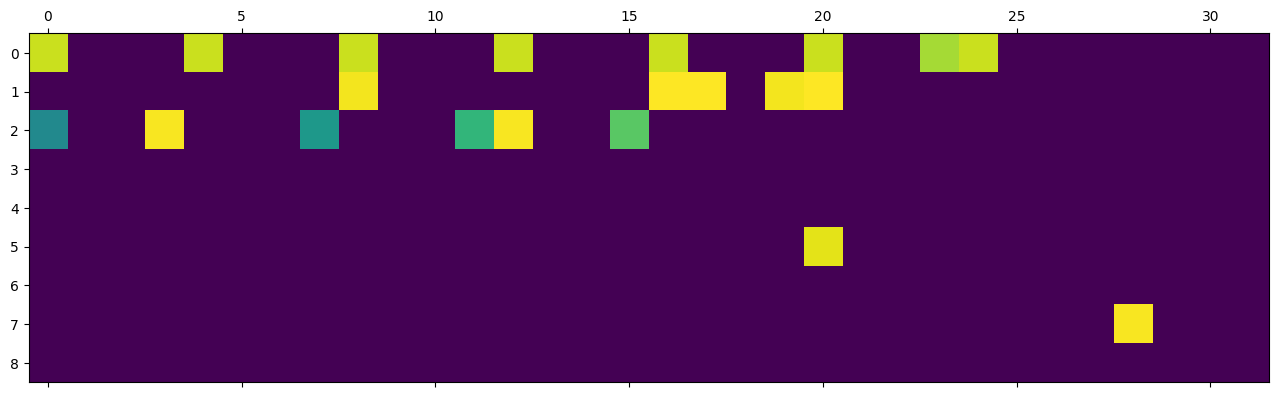

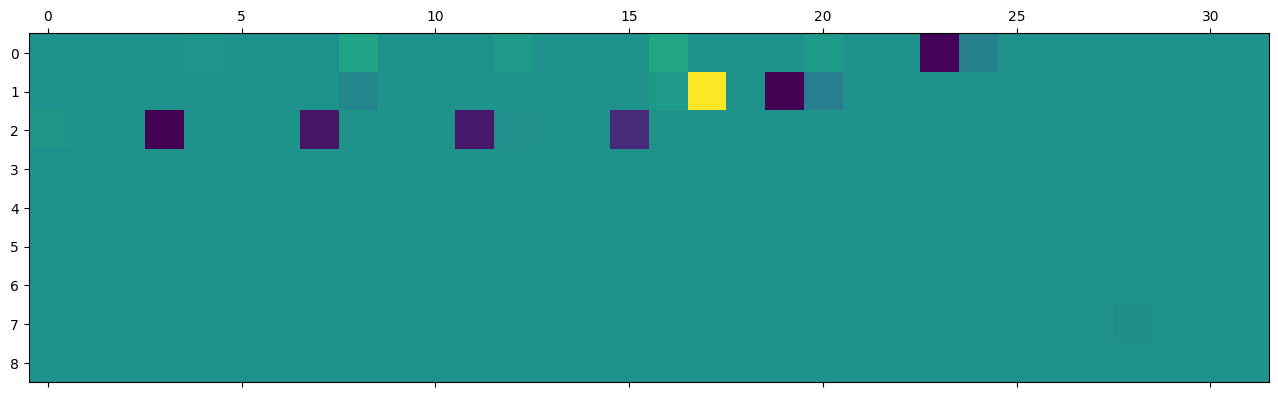

---------------------------
robotic 150000


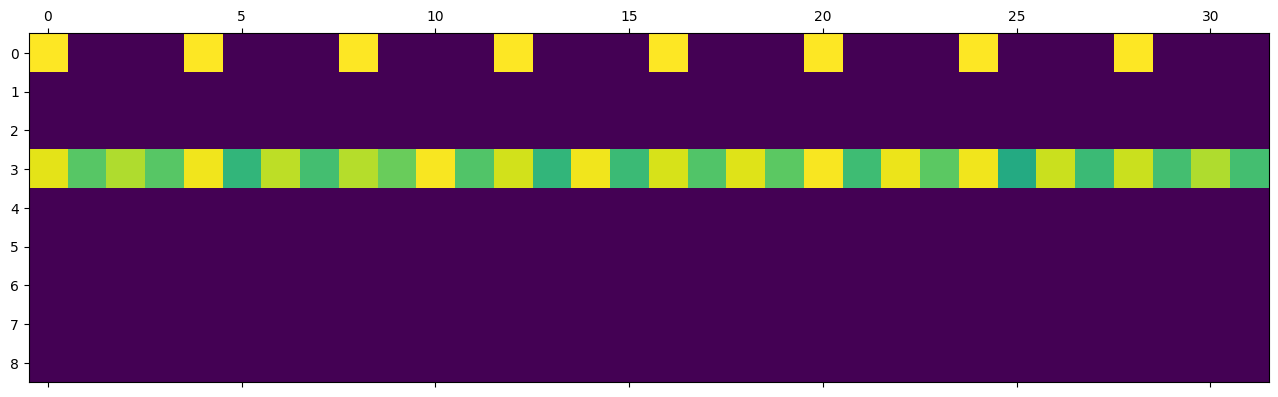

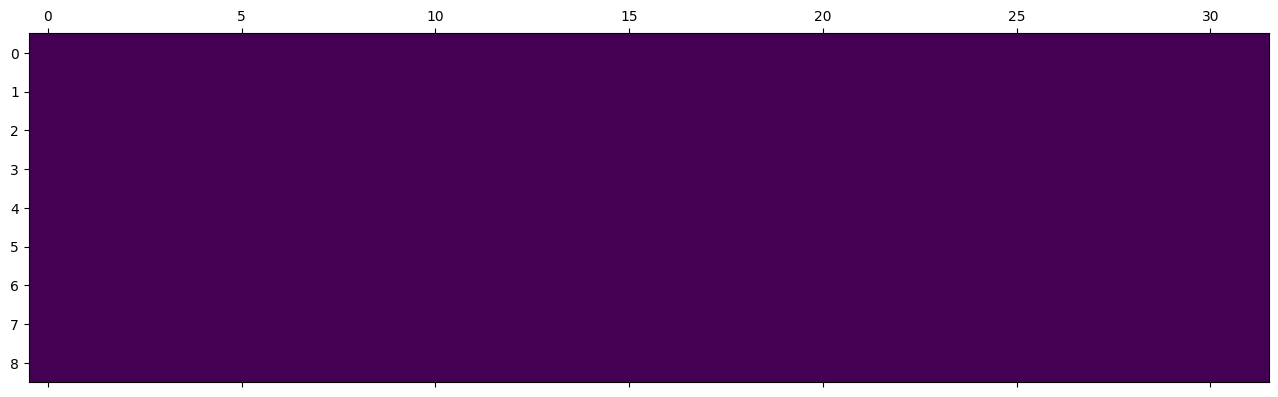

---------------------------


In [5]:
for i, genre in enumerate(GENRES):
    a = matrices_drums[matrices_genres == i]
    t = matrices_offsets[matrices_genres == i]
    print(genre, int(a.shape[0]))
    plot_drum_matrix(a[0])
    plot_drum_matrix(t[0])
    play_drum_matrix(a[0])
    print("---------------------------")

In [ ]:
import numpy as np
# Remove all these direct keras imports since they're already available from the optimized imports
# from keras.layers import Input, Dense, Flatten, Dropout, Reshape, LSTM
# from keras.layers import Bidirectional, Lambda, Concatenate, Softmax, BatchNormalization
# from keras.layers.advanced_activations import LeakyReLU
# from keras.optimizers import RMSprop
# from keras.models import Model
# from keras import regularizers

droprate = 0.4

# input
drum_input = Input(shape=(len_seq, nb_notes), name='drum_input')  # tensorflow order
offset_input = Input(shape=(len_seq, nb_notes), name='offset_input')  # tensorflow order

x0 = Bidirectional(LSTM(128, return_sequences=True, activation='tanh', dropout=droprate, recurrent_dropout=droprate))(drum_input) 
x0 = BatchNormalization()(x0)
x0 = Bidirectional(LSTM(128, return_sequences=False, activation='tanh', dropout=droprate, recurrent_dropout=droprate))(x0)
x0 = BatchNormalization()(x0)
#x0 = Dropout(droprate)(x0)

x1 = Bidirectional(LSTM(128, return_sequences=True, activation='tanh', dropout=droprate, recurrent_dropout=droprate))(offset_input) 
x1 = BatchNormalization()(x1)
x1 = Bidirectional(LSTM(128, return_sequences=False, activation='tanh', dropout=droprate, recurrent_dropout=droprate))(x1)
x1 = BatchNormalization()(x1)
#x1 = Dropout(droprate)(x1)

x = Concatenate(axis=-1)([x0, x1])
x = Dropout(droprate)(x)
x = Dense(512, activation='sigmoid')(x)
output = Dense(NB_GENRES, activation='softmax', 
               kernel_regularizer=regularizers.l2(0.01), 
               activity_regularizer=regularizers.l1(0.01))(x)

model = Model([drum_input, offset_input], output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drum_input          │ (None, 32, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ offset_input        │ (None, 32, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 256)   │    141,312 │ drum_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 32, 256)   │    141,312 │ offset_input[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 256)   │      1,024 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 256)       │    394,240 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 256)       │    394,240 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ bidirectional_3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │      1,026 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,338,882 (5.11 MB)

 Trainable params: 1,336,834 (5.10 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [7]:
# from tensorboard_logger import configure, log_value

from datetime import datetime
now = datetime.now()
logdir_prefix = "/tmp/tf_logs_classification/"
logdir = logdir_prefix + now.strftime("%Y%m%d-%H%M%S") 
cmd = "tensorboard --logdir=" + logdir_prefix
print (cmd)

# configure(logdir, flush_secs=5)

tensorboard --logdir=/tmp/tf_logs_classification/


In [21]:
import tensorflow as tf
from tensorflow.keras import mixed_precision, regularizers, layers, models

# 1.  Mixed precision on M1/M2 gives 1.3-2× speed-up for LSTMs despite no CuDNN
mixed_precision.set_global_policy("mixed_float16")

# 2.  Remove recurrent_dropout; keep normal dropout
LSTM_DROPOUT = 0.2

# 3.  Use tf.data with caching, prefetch and larger batch
BATCH_SIZE = 512
ds = tf.data.Dataset.from_tensor_slices(
        ((matrices_onsets, matrices_offsets), genre_ids)
     ).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE).cache()

# 4.  Build model once
input_on = layers.Input((len_seq, nb_notes), name="onsets")
input_off = layers.Input((len_seq, nb_notes), name="offsets")

def stack(x):
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=LSTM_DROPOUT)
        )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(
            layers.LSTM(128, dropout=LSTM_DROPOUT)
        )(x)
    x = layers.BatchNormalization()(x)
    return x

x = layers.Concatenate()([stack(input_on), stack(input_off)])
x = layers.Dropout(LSTM_DROPOUT)(x)
x = layers.Dense(512, activation="relu")(x)          # use ReLU, faster than sigmoid
out = layers.Dense(
        NB_GENRES,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-3),
        activity_regularizer=regularizers.l1(1e-3),
        dtype="float32"        # ← forces logits & loss to fp32
)(x)

model = models.Model([input_on, input_off], out)
opt = tf.keras.optimizers.RMSprop(learning_rate=2e-3)
model.compile(opt, loss="categorical_crossentropy", metrics=["accuracy"])

# 5.  Lighter callbacks
es  = tf.keras.callbacks.EarlyStopping("val_loss", patience=10, restore_best_weights=True)
cp  = tf.keras.callbacks.ModelCheckpoint("tmp/best.keras", save_best_only=True)
lr  = tf.keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.5, patience=3)

NUM_SAMPLES = matrices_onsets.shape[0]
split_idx   = int(0.8 * NUM_SAMPLES)          # 80 / 20 split

full_ds = full_ds.map(
    lambda inputs, y: ((tf.cast(inputs[0], tf.float16),
                        tf.cast(inputs[1], tf.float16)),
                       y)          # y already float32 thanks to last layer
)

train_ds = full_ds.take(split_idx).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE).cache()
val_ds   = full_ds.skip(split_idx).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE).cache()

history  = model.fit(
    train_ds,
    validation_data=val_ds,          # ← use this instead of validation_split
    epochs=100,
    callbacks=[es, cp, lr],
    verbose=2,
)

Epoch 1/100
285/285 - 49s - 173ms/step - accuracy: 0.8319 - loss: 2.9802 - val_accuracy: 0.9287 - val_loss: 1.6692 - learning_rate: 0.0020
Epoch 2/100
285/285 - 36s - 126ms/step - accuracy: 0.9437 - loss: 3.5593 - val_accuracy: 0.3912 - val_loss: 13.5138 - learning_rate: 0.0020
Epoch 3/100
285/285 - 37s - 128ms/step - accuracy: 0.9561 - loss: 4.2484 - val_accuracy: 0.9930 - val_loss: 0.6336 - learning_rate: 0.0020
Epoch 4/100
285/285 - 36s - 127ms/step - accuracy: 0.9573 - loss: 5.2402 - val_accuracy: 0.9891 - val_loss: 0.8605 - learning_rate: 0.0020
Epoch 5/100
285/285 - 36s - 127ms/step - accuracy: 0.9684 - loss: 5.4560 - val_accuracy: 0.9925 - val_loss: 0.8329 - learning_rate: 0.0020
Epoch 6/100
285/285 - 36s - 127ms/step - accuracy: 0.9750 - loss: 4.9975 - val_accuracy: 0.9751 - val_loss: 2.1270 - learning_rate: 0.0020
Epoch 7/100
285/285 - 36s - 127ms/step - accuracy: 0.9830 - loss: 1.6937 - val_accuracy: 0.9972 - val_loss: 0.6375 - learning_rate: 0.0010
Epoch 8/100
285/285 - 36s 

In [ ]:
# ------------------------------------------------------------
#  Rhythm-style classifier — resume training from epoch 22
#  (c) your notebook
# ------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau, TerminateOnNaN,
                                        LambdaCallback)
from tensorflow.keras.metrics import CategoricalCrossentropy
import numpy as np
import sklearn.metrics as skm
import os, pathlib

# ---------- 0. mixed-precision policy ----------
mixed_precision.set_global_policy("mixed_float16")        # Apple-silicon speed-up 🏎️

# ---------- 1. constants ----------
BATCH_SIZE   = 512
LSTM_DROPOUT = 0.20
CHECKPOINT   = pathlib.Path("tmp/best.keras")              # same path you used before
START_EPOCH  = 22                                          # last *finished* epoch

# ---------- 2. make data float16 to match policy ----------
matrices_onsets  = matrices_onsets.astype("float16")
matrices_offsets = matrices_offsets.astype("float16")

# ---------- 3. tf.data pipeline ----------
full_ds   = tf.data.Dataset.from_tensor_slices(
              ((matrices_onsets, matrices_offsets), genre_ids)
            ).shuffle(10_000, seed=42, reshuffle_each_iteration=False)

split_idx = int(0.8 * len(matrices_onsets))
train_ds  = (full_ds.take(split_idx)
             .batch(BATCH_SIZE)
             .prefetch(tf.data.AUTOTUNE)
             .cache())                                    # cache train only
val_ds    = (full_ds.skip(split_idx)
             .batch(BATCH_SIZE)
             .prefetch(tf.data.AUTOTUNE))                 # no cache → fewer NaN glitches

# ---------- 4. model definition ----------
def stack(x):
    x = layers.Bidirectional(layers.LSTM(128,
                                         return_sequences=True,
                                         dropout=LSTM_DROPOUT))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(layers.LSTM(128,
                                         dropout=LSTM_DROPOUT))(x)
    x = layers.BatchNormalization()(x)
    return x

inp_on   = layers.Input((len_seq, nb_notes), name="onsets")
inp_off  = layers.Input((len_seq, nb_notes), name="offsets")

x = layers.Concatenate()([stack(inp_on), stack(inp_off)])
x = layers.Dropout(LSTM_DROPOUT)(x)
x = layers.Dense(512, activation="relu")(x)
out = layers.Dense(NB_GENRES,
                   activation="softmax",
                   kernel_regularizer=regularizers.l2(1e-3),
                   activity_regularizer=regularizers.l1(1e-3),
                   dtype="float32")(x)                     # logits & loss in fp32

model = models.Model([inp_on, inp_off], out)

# ---------- 5. compile ----------
opt = tf.keras.optimizers.RMSprop(1e-3, clipnorm=1.0)      # gradient-clipping
model.compile(optimizer=opt,
              loss="categorical_crossentropy",
              metrics=["accuracy",
                       CategoricalCrossentropy(name="ce")])# ‘ce’ = pure cross-entropy

# ---------- 6. load checkpoint if available ----------
if CHECKPOINT.exists():
    model.load_weights(CHECKPOINT)
    print(f"✓ Loaded weights from {CHECKPOINT}")

# ---------- 7. callbacks ----------
es  = EarlyStopping("val_loss", patience=10, restore_best_weights=True)
cp  = ModelCheckpoint(CHECKPOINT, save_best_only=True)
lr  = ReduceLROnPlateau("val_loss", factor=0.3, patience=2, min_lr=1e-6)
nan = TerminateOnNaN()

def cm_report(logs=None):                          # <— only ONE positional argument
    y_pred = model.predict(val_ds, verbose=0).argmax(1)
    y_true = np.concatenate([y for _, y in val_ds]).argmax(1)
    print("\n===== FINAL VALIDATION REPORT =====")
    print(skm.classification_report(y_true, y_pred, digits=4))
    print("Confusion matrix:\n", skm.confusion_matrix(y_true, y_pred))

cm  = LambdaCallback(on_train_end=cm_report)

callbacks = [es, cp, lr, nan, cm]

# ---------- 8. resume training ----------
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=100,
                    initial_epoch=START_EPOCH,   # resume from last completed epoch
                    callbacks=callbacks,
                    verbose=2)

# ------------------------------------------------------------
#  End of cell
# ------------------------------------------------------------

✓ Loaded weights from tmp/best.keras
Epoch 23/100


/opt/anaconda3/envs/creative-gan/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/anaconda3/envs/creative-gan/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


285/285 - 48s - 170ms/step - accuracy: 0.9052 - ce: 15.7566 - loss: 16.2813 - val_accuracy: 0.9131 - val_ce: 9.1799 - val_loss: 9.7040 - learning_rate: 0.0010
Epoch 24/100
285/285 - 39s - 137ms/step - accuracy: 0.9027 - ce: 21.4401 - loss: 21.9644 - val_accuracy: 0.8179 - val_ce: 33.3758 - val_loss: 33.9012 - learning_rate: 0.0010
Epoch 25/100
285/285 - 39s - 137ms/step - accuracy: 0.9005 - ce: 28.3274 - loss: 28.8537 - val_accuracy: 0.8069 - val_ce: 28.9718 - val_loss: 29.4990 - learning_rate: 0.0010
Epoch 26/100
285/285 - 39s - 138ms/step - accuracy: 0.9098 - ce: 33.8756 - loss: 34.4028 - val_accuracy: 0.7097 - val_ce: 47.0081 - val_loss: 47.5334 - learning_rate: 3.0000e-04
Epoch 27/100
285/285 - 39s - 136ms/step - accuracy: 0.9153 - ce: 25.4822 - loss: 26.0080 - val_accuracy: 0.7500 - val_ce: 37.9321 - val_loss: 38.4561 - learning_rate: 3.0000e-04
Epoch 28/100
285/285 - 38s - 133ms/step - accuracy: 0.9184 - ce: 24.3022 - loss: 24.8271 - val_accuracy: 0.7962 - val_ce: 17.5375 - val_l

TypeError: cm_report() missing 1 required positional argument: '__'

In [ ]:
model.save("./tmp/rhythm_classification_groove_with_offset.h5")